# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name:  DGIM

Created by NAMES (SJSU IDs): Grant Biellak, Duc Nguyen, Ido Belyaev, Michael Hamaty  (017180631)

Last updated: DATE  

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

In [1]:
from datasets import load_dataset
import pandas as pd
dataset = load_dataset("electricsheepafrica/nigerian-banking-bnpl")
df = dataset["train"].to_pandas()
df



'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/datasets/electricsheepafrica/nigerian-banking-bnpl/resolve/b6fa7f43ae5ce15ed068403b8a80256a7d9cd517/nigerian-banking-bnpl.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since electricsheepafrica/nigerian-banking-bnpl couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/michaelhamaty/.cache/huggingface/datasets/electricsheepafrica___nigerian-banking-bnpl/default/0.0.0/b6fa7f43ae5ce15ed068403b8a80256a7d9cd517 (last modified on Wed Mar 25 17:15:39 2026).


,transaction_id,purchase_date,customer_id,merchant_category,merchant_name,customer_state,principal_ngn,interest_rate_monthly,tenor_days,num_installments,provider,credit_score,first_time_customer,first_payment_due,default_30d,default_90d
0,BNPL-0000274330,2024-07-10,CUS-00036437,groceries,Groceries Store 105,Oyo,35416.989135,0.000000,14,1,FairMoney,645,False,2024-08-09,False,False
1,BNPL-0001873807,2023-08-01,CUS-00131005,furniture,Furniture Store 820,Lagos,43154.846706,0.000000,30,1,FairMoney,716,True,2023-08-31,False,False
2,BNPL-0001029126,2022-02-12,CUS-00648656,electronics,Electronics Store 346,Abuja (FCT),247235.615112,0.000000,14,1,Branch,470,False,2022-03-14,False,False
3,BNPL-0001512791,2023-01-26,CUS-00611557,furniture,Furniture Store 393,Lagos,70679.217230,0.032728,30,1,Branch,620,False,2023-02-25,False,False
4,BNPL-0000552055,2023-01-12,CUS-00499951,fashion,Fashion Store 956,Ekiti,225083.504313,0.049655,90,3,Branch,536,False,2023-02-11,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,BNPL-0000368650,2024-05-05,CUS-00156492,fashion,Fashion Store 571,Abuja (FCT),12623.449026,0.032469,60,2,PayLater,537,False,2024-06-04,False,False
1999996,BNPL-0001476894,2023-02-16,CUS-00645549,electronics,Electronics Store 451,Rivers,45869.744635,0.025534,30,1,FairMoney,661,False,2023-03-18,False,False
1999997,BNPL-0001091970,2022-04-28,CUS-00359886,electronics,Electronics Store 219,Kaduna,31642.169721,0.035212,30,1,Carbon,544,True,2022-05-28,False,True
1999998,BNPL-0001791429,2024-09-01,CUS-00324171,electronics,Electronics Store 616,Abuja (FCT),36137.678738,0.025662,60,2,Branch,576,False,2024-10-01,False,False


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 16 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   transaction_id         object        
 1   purchase_date          datetime64[ns]
 2   customer_id            object        
 3   merchant_category      object        
 4   merchant_name          object        
 5   customer_state         object        
 6   principal_ngn          float64       
 7   interest_rate_monthly  float64       
 8   tenor_days             int64         
 9   num_installments       int64         
 10  provider               object        
 11  credit_score           int64         
 12  first_time_customer    bool          
 13  first_payment_due      datetime64[ns]
 14  default_30d            bool          
 15  default_90d            bool          
dtypes: bool(3), datetime64[ns](2), float64(2), int64(3), object(6)
memory usage: 204.1+ MB


## Taking a look at the data itself
We see the dataframe contains 200,000 rows and 16 columns. The headers have loaded in properly and formatiing looks good. No issue with the dataframe itself.

With this said, we can see many columns with the datatype 'object' 

In [4]:
#some minimal data cleaning
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].str.strip()

df["merchant_category"] = df["merchant_category"].str.lower()
df["customer_state"]    = df["customer_state"].str.lower()
df["provider"]          = df["provider"].str.lower()

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

Lets list out the categorical columns that exist in the dataframe:

* merchant_category
* merchant_name
* customer_state
* provider

Q1: lets see merchant cetegory & merchant name, with provider as the hue


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

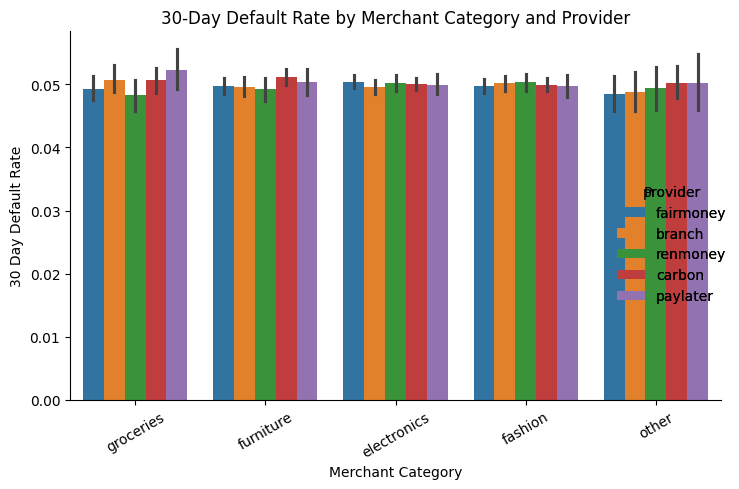

In [14]:
graph = sns.catplot(
    data=df,
    x="merchant_category",
    y="default_30d",
    hue="provider",
    kind="bar",
    height=5,
)
graph.set_axis_labels("Merchant Category", "30 Day Default Rate")
graph.set_xticklabels(rotation=30)
plt.title("30-Day Default Rate by Merchant Category and Provider")
graph.add_legend(title="Provider")
plt.tight_layout()
plt.show()

### Q3: Come up with a another unique question. This question must use map() or apply()

lets investigate if higher credit scores have lower default rates. for this problem, lets create a condition to determine whether a credit score is good, decent, bad, and terrible -> from there we map that to the existing credit score column in order to make a a credit_tier column

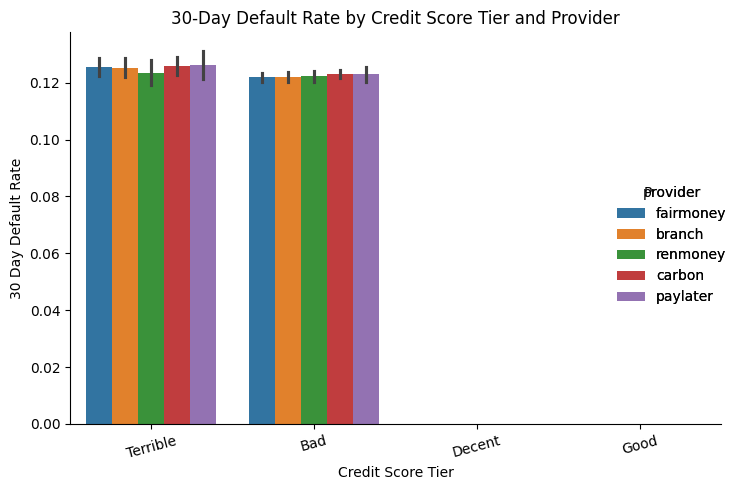

In [13]:
def score_to_tier(score):
    if score >= 700:
        return "Good"
    elif score >= 600:
        return "Decent"
    elif score >= 500:
        return "Bad"
    else:
        return "Terrible"

# Now map to credit_score
df["credit_tier"] = df["credit_score"].map(score_to_tier)

# Define the display order for the credit tiers
tier_order = ["Terrible", "Bad", "Decent", "Good"]

map_graph = sns.catplot(
    data=df,
    x="credit_tier",
    y="default_30d",
    hue="provider",
    kind="bar",
    order=tier_order,
    height=5)

map_graph.set_axis_labels("Credit Score Tier", "30 Day Default Rate")
map_graph.set_xticklabels(rotation=15)
plt.title("30-Day Default Rate by Credit Score Tier and Provider")
map_graph.add_legend(title="Provider")
plt.tight_layout()
plt.show()

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [ ]:
# Your code here . . .

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

In [ ]:
# Your code here . . .